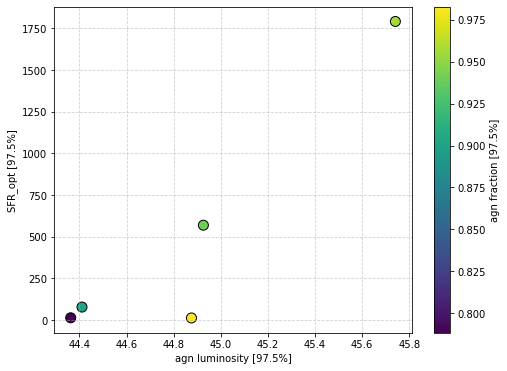

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

output_dir = 'fantasy310_env/AGNfitter/OUTPUT/'
param_files = glob.glob(os.path.join(output_dir, '*', 'parameter_outvalues_*.txt'))

sfr_opt_975 = []
lbb_dered_975 = []
agn_frac_975 = []
source_names = []


for filepath in param_files:
    source_names.append(os.path.basename(os.path.dirname(filepath)))
    df = pd.read_csv(filepath, delim_whitespace=True, skiprows=3)
    # 97.5 percentile is 5th row 
    sfr_opt_975.append(df['SFR_opt'].iloc[4])
    lbb_dered_975.append(df['Lbbdered(0.1-1)'].iloc[4])
    agn_frac_975.append(df['AGNfrac(0.1-1)'].iloc[4])

# scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(lbb_dered_975, sfr_opt_975, c=agn_frac_975, cmap='viridis', s=100, edgecolor='k')
plt.colorbar(scatter, label='agn fraction [97.5%]')
plt.xlabel('agn luminosity [97.5%]')
plt.ylabel('SFR_opt [97.5%]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

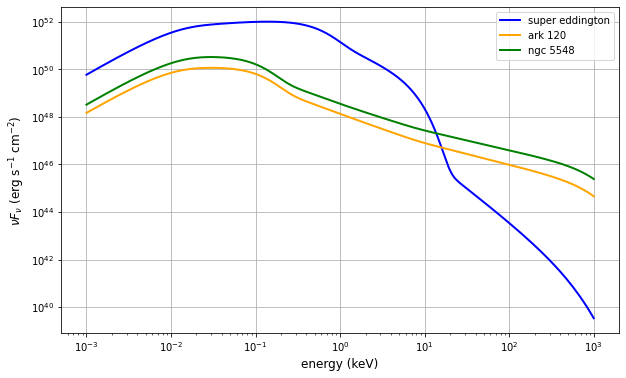

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
from qsosed.sed import SED

def create_agn_model(mass, spin, mdot, distance_mpc):
    agn = SED()
    agn.M = mass
    agn.a = spin        
    agn.mdot = mdot
    try:
        agn.r_hot = 10
        agn.r_warm = 20
    except AttributeError:
        pass 
    flux = agn.total_flux(distance_mpc) 
    # find frequency/energy array and convert to keV
    if hasattr(agn, 'nu'):
        energy_kev = agn.nu * 4.135667696e-18  
    elif hasattr(agn, 'lognu'):
        energy_kev = (10**agn.lognu) * 4.135667696e-18
    elif hasattr(agn, 'energy'):
        energy_kev = agn.energy
    else:
        energy_kev = np.logspace(-3, 3, len(flux))
    return energy_kev, flux

# agn models 
e_super, flux_super = create_agn_model(mass=2e6, spin=0.9, mdot=1.0, distance_mpc=180)
e_ark, flux_ark = create_agn_model(mass=1.5e8, spin=0.83, mdot=0.1, distance_mpc=140)
e_ngc, flux_ngc = create_agn_model(mass=6.5e7, spin=0.0, mdot=0.03, distance_mpc=72)

# plot
plt.figure(figsize=(10, 6))
plt.plot(e_super, flux_super, label='super eddington', color='blue', lw=2)
plt.plot(e_ark, flux_ark, label='ark 120', color='orange', lw=2)
plt.plot(e_ngc, flux_ngc, label='ngc 5548', color='green', lw=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('energy (keV)', fontsize=12)
plt.ylabel(r'$\nu F_\nu$ (erg s$^{-1}$ cm$^{-2}$)', fontsize=12)
plt.legend()
plt.grid()
plt.show()